# Inference: Using the Model
Now that we have trained the model and saved it as a `.pth` file, we can use it!
This notebook loads the saved brain and lets you test it on one single image.

In [1]:
# 2_inference.ipynb

import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
import requests
from io import BytesIO


## Step 1: Rebuild and Load the Brain
We have to build the empty MobileNet structure first, and then fill it with the "knowledge" (weights) we saved in the previous notebook.

In [2]:

# --- CONFIGURATION ---
MODEL_PATH = 'best_mobilenet.pth'

# Note: You can change IMAGE_PATH to any image on your computer!

# Same classes as before (Make sure these match your folders!)
CLASS_NAMES = ['ants', 'bees'] 

# Detect device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- STEP 1: RELOAD THE MODEL ---
print("Loading model architecture...")
model = models.mobilenet_v2(weights=None) # We don't need internet weights, we have our own
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, len(CLASS_NAMES))

print(f"Loading weights from {MODEL_PATH}...")
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval() # Set to evaluation mode (essential for inference!)

# --- STEP 2: PREPARE THE SINGLE IMAGE ---
# We must apply the exact same transforms we used during training
inference_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def predict_image(image_source):
    # Check if the input is a URL (starts with http or https)
    if image_source.startswith(('http://', 'https://')):
        try:
            response = requests.get(image_source)
            response.raise_for_status() # Check for download errors
            # turn the downloaded data into a file-like object
            image = Image.open(BytesIO(response.content)).convert('RGB')
        except Exception as e:
            print(f"Error loading URL: {e}")
            return
    
    # Check if the input is a local file path
    elif os.path.exists(image_source):
        image = Image.open(image_source).convert('RGB')
        
    else:
        print(f"Error: Image not found at {image_source}")
        return

    # --- DISPLAY IMAGE ---
    plt.imshow(image)
    plt.axis('off')
    plt.show()

    # --- PREPARE FOR MODEL ---
    # Transform image and add batch dimension [Batch, Channel, Height, Width]
    image_tensor = inference_transforms(image).unsqueeze(0).to(device)

    # --- PREDICT ---
    with torch.no_grad():
        outputs = model(image_tensor)
        
        # Calculate percentages
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted_class_index = torch.max(probabilities, 1)
    
    predicted_label = CLASS_NAMES[predicted_class_index.item()]
    confidence_score = confidence.item() * 100

    print(f"Prediction: {predicted_label}")
    print(f"Confidence: {confidence_score:.2f}%")


Loading model architecture...
Loading weights from best_mobilenet.pth...


## Step 2: Predict!
We define a function that:
1. Opens an image.
2. Resizes it to 224x224 (just like we did during training).
3. Asks the model for a probability.

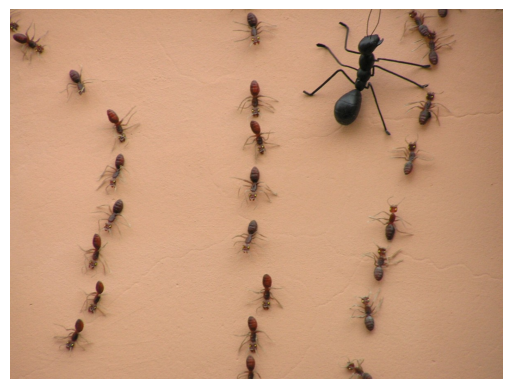

Prediction: ants
Confidence: 87.57%


In [6]:

IMAGE_PATH = "https://gardenerspath.com/wp-content/uploads/2024/01/Buzz-About-Bees-Feature.jpg"
IMAGE_PATH = "IMG_0561.jpeg"
# --- RUN INFERENCE ---
predict_image(IMAGE_PATH)